# 🎓 Mega Professional Prompt — Student Habits & Performance ML Pipeline

---

## 🧠 CONTEXT & DATASET OVERVIEW

You are a senior data scientist working with a real-world educational dataset called **`enhanced_student_habits_performance_dataset.csv`**, containing **~80,000 student records** across **31 columns**. The dataset captures a rich set of behavioral, demographic, academic, and psychological features aimed at predicting student **exam scores** (the target variable — a continuous numeric value ranging roughly from 50–100).

### 📋 Column Reference

| Column | Type | Description |
|--------|------|-------------|
| `student_id` | Integer | Unique student identifier (range: 100000–179999) |
| `age` | Integer | Student age (16–28) |
| `gender` | Categorical | Male / Female / Other |
| `major` | Categorical | Computer Science, Arts, Biology, Business, Engineering, Psychology |
| `study_hours_per_day` | Float | Daily study hours — **contains precision inconsistencies** (some values are excessively long floats like `7.64536653374835`) |
| `social_media_hours` | Float | Daily social media usage hours |
| `netflix_hours` | Float | Daily Netflix/streaming hours |
| `part_time_job` | Binary | Yes / No |
| `attendance_percentage` | Float | Class attendance (%) |
| `sleep_hours` | Float | Daily sleep hours |
| `diet_quality` | Ordinal | Poor / Fair / Good |
| `exercise_frequency` | Integer | Times per week (0–7) |
| `parental_education_level` | Ordinal | High School / Some College / Bachelor / Master / PhD |
| `internet_quality` | Ordinal | Low / Medium / High |
| `mental_health_rating` | Float | Self-reported mental health score (1–10) — **contains floating-point precision issues** (e.g., `7.300000000000001`) |
| `extracurricular_participation` | Binary | Yes / No |
| `previous_gpa` | Float | Previous semester GPA (0.0–4.0) |
| `semester` | Integer | Current semester number (1–8) |
| `stress_level` | Float | Self-reported stress score (1–10) |
| `dropout_risk` | Binary | Yes / No — **NOTE: highly imbalanced, mostly "No"** |
| `social_activity` | Integer | Social activity score (0–5) |
| `screen_time` | Float | Total daily screen time (hours) — **derived from social_media + netflix + others; verify consistency** |
| `study_environment` | Categorical | Library / Quiet Room / Dorm / Cafe / Co-Learning Group |
| `access_to_tutoring` | Binary | Yes / No |
| `family_income_range` | Ordinal | Low / Medium / High |
| `parental_support_level` | Ordinal | Low / Medium / High / 1–10 numeric — **INCONSISTENCY: mixed types** |
| `motivation_level` | Integer | Motivation score (1–10) |
| `exam_anxiety_score` | Integer | Exam anxiety score (5–10) |
| `learning_style` | Categorical | Visual / Auditory / Reading / Kinesthetic |
| `time_management_score` | Float | Time management score (1–10) |
| `exam_score` | Integer | **TARGET VARIABLE** — Final exam score (50–100) |

---

## 📌 KNOWN DATASET ISSUES TO ADDRESS

Before proceeding with any analysis, be aware of the following issues that **must be corrected**:

1. **Column name inconsistencies**: Some column names use mixed conventions (e.g., `parental_support_level` vs `parental_education_level` naming style is fine, but verify all names follow `snake_case`).
2. **Floating-point precision errors**: Columns like `study_hours_per_day` (e.g., `7.64536653374835`) and `mental_health_rating` (e.g., `7.300000000000001`) have excessive precision likely due to floating-point arithmetic errors — round appropriately (1–2 decimal places).
3. **Mixed-type columns**: `parental_support_level` appears to contain both text levels (Low/Medium/High) AND numeric strings — standardize to consistent ordinal text categories.
4. **`screen_time` column validation**: This column appears to be a derived feature. Validate whether it is consistently equal to `social_media_hours + netflix_hours + other_screen_time` or if it introduces redundancy/noise.
5. **Potential outliers**: Columns like `study_hours_per_day` may contain values exceeding realistic daily study limits (e.g., >12 hours). Flag and handle appropriately.
6. **`dropout_risk` imbalance**: This column is heavily skewed toward "No" — note this if used as a classification target (not the main target here, but mention it).
7. **`student_id` is not a feature** — must be dropped before modeling.

---

## 📦 Step 0: Environment Setup
Import all required libraries. We will use pandas and numpy for data manipulation, 
matplotlib and seaborn for visualization, sklearn for preprocessing, feature 
selection, and modeling, and xgboost/lightgbm for gradient boosting models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression, RFE, RFECV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


## 📥 Step 1: Data Loading & First Look
Load the dataset and perform an initial inspection to understand its shape, 
data types, and surface-level issues before cleaning begins.


In [2]:
df = pd.read_csv('enhanced_student_habits_performance_dataset.csv')

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()


Shape: (80000, 31)

Column Names: ['student_id', 'age', 'gender', 'major', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'study_environment', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'learning_style', 'time_management_score', 'exam_score']

Data Types:
 student_id                         int64
age                                int64
gender                            object
major                             object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            flo

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


## 🛠️ Step 2: Preprocessing & Dataset Correction
This step addresses structural issues in the dataset:
- Dropping the non-informative `student_id` column
- Fixing floating-point precision in `study_hours_per_day` and `mental_health_rating`
- Standardizing `parental_support_level` from mixed numeric/text format to consistent ordinal strings
- Validating and handling `screen_time` redundancy
- Renaming any misnamed columns if needed
These corrections ensure the data is structurally sound before any analysis.


In [3]:
# Drop student_id
df.drop(columns=['student_id'], inplace=True)

# Fix floating point precision
df['study_hours_per_day'] = df['study_hours_per_day'].round(2)
df['mental_health_rating'] = df['mental_health_rating'].round(1)

# Standardize parental_support_level: map any numeric values to labels
def fix_support_level(val):
    try:
        val_num = float(val)
        if val_num <= 3: return 'Low'
        elif val_num <= 6: return 'Medium'
        else: return 'High'
    except (ValueError, TypeError):
        return str(val).strip().capitalize()

df['parental_support_level'] = df['parental_support_level'].apply(fix_support_level)

# Validate screen_time — check if it approximately equals social_media + netflix
df['screen_time_check'] = df['social_media_hours'] + df['netflix_hours']
correlation = df['screen_time'].corr(df['screen_time_check'])
print(f"screen_time vs (social_media + netflix) correlation: {correlation:.4f}")
# If correlation > 0.95, screen_time is largely redundant — decide to keep or drop
# Decision: keep screen_time as it likely includes device/study screen time too

df.drop(columns=['screen_time_check'], inplace=True)

print("Corrections applied. Dataset shape:", df.shape)
df.dtypes


screen_time vs (social_media + netflix) correlation: 0.6613
Corrections applied. Dataset shape: (80000, 30)


age                                int64
gender                            object
major                             object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating             float64
extracurricular_participation     object
previous_gpa                     float64
semester                           int64
stress_level                     float64
dropout_risk                      object
social_activity                    int64
screen_time                      float64
study_environment                 object
access_to_tutoring                object
family_income_range               object
parental_support

## 🔍 Step 3: Missing Value Detection & Imputation
We scan all columns for null values and apply context-aware imputation strategies:
- Numerical columns: impute with median (robust to outliers)
- Categorical/ordinal columns: impute with mode (most frequent value)
- We avoid dropping rows unless missingness exceeds 30% of a column, 
  as this dataset represents real student behavior and data loss matters.
We will visualize the missing data heatmap and bar chart before and after imputation.


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


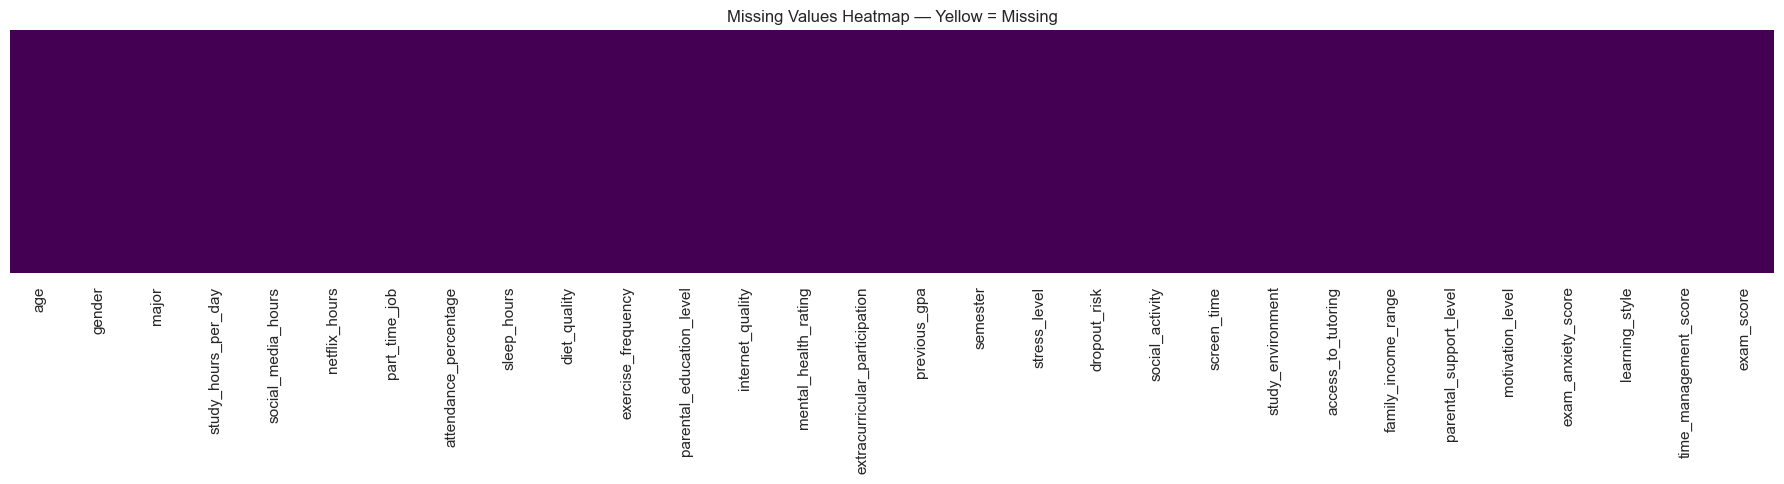

In [4]:
# Missing value count and percentage
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

# Visualization: Missing value heatmap
plt.figure(figsize=(18, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap — Yellow = Missing')
plt.tight_layout()
plt.show()


**📊 Chart Description:** This heatmap displays the presence of missing values across all columns (x-axis) for every row (y-axis). Yellow streaks indicate missing entries. If the chart appears mostly dark/purple with minimal yellow, missingness is low and localized. Key observation: identify which columns have systematic vs. random missingness patterns. If a column shows vertical yellow bands, it indicates structured missing data possibly tied to a survey design decision (e.g., `parental_support_level` only asked for certain demographics).


In [5]:
# Imputation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after imputation:", df.isnull().sum().sum())


Missing values after imputation: 0


## 🔁 Step 4: Duplicate Records
Duplicate records can skew model training by over-representing certain patterns.
We check for exact duplicates and remove them while logging the count removed.
We also check for near-duplicate records based on key features if exact matches exist.


In [6]:
print(f"Total records before dedup: {len(df)}")
n_dups = df.duplicated().sum()
print(f"Exact duplicates found: {n_dups}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Total records after dedup: {len(df)}")


Total records before dedup: 80000
Exact duplicates found: 0
Total records after dedup: 80000


## 📊 Step 5: Outlier Detection & Handling
Outliers can severely distort model training, especially for regression tasks.
We use the IQR (Interquartile Range) method to detect outliers in all numerical columns.
For each column, we evaluate whether the outlier is:
- A data entry error → clip to the valid domain boundary
- A rare but realistic student behavior → keep or winsorize at the 1st/99th percentile

Domain knowledge bounds applied:
- study_hours_per_day: 0–16 hours (max realistic)
- sleep_hours: 2–14 hours
- attendance_percentage: 0–100
- exam_score: 0–100
- mental_health_rating, stress_level, motivation_level: 1–10
- exercise_frequency: 0–7 (days per week)
- screen_time: 0–24 hours


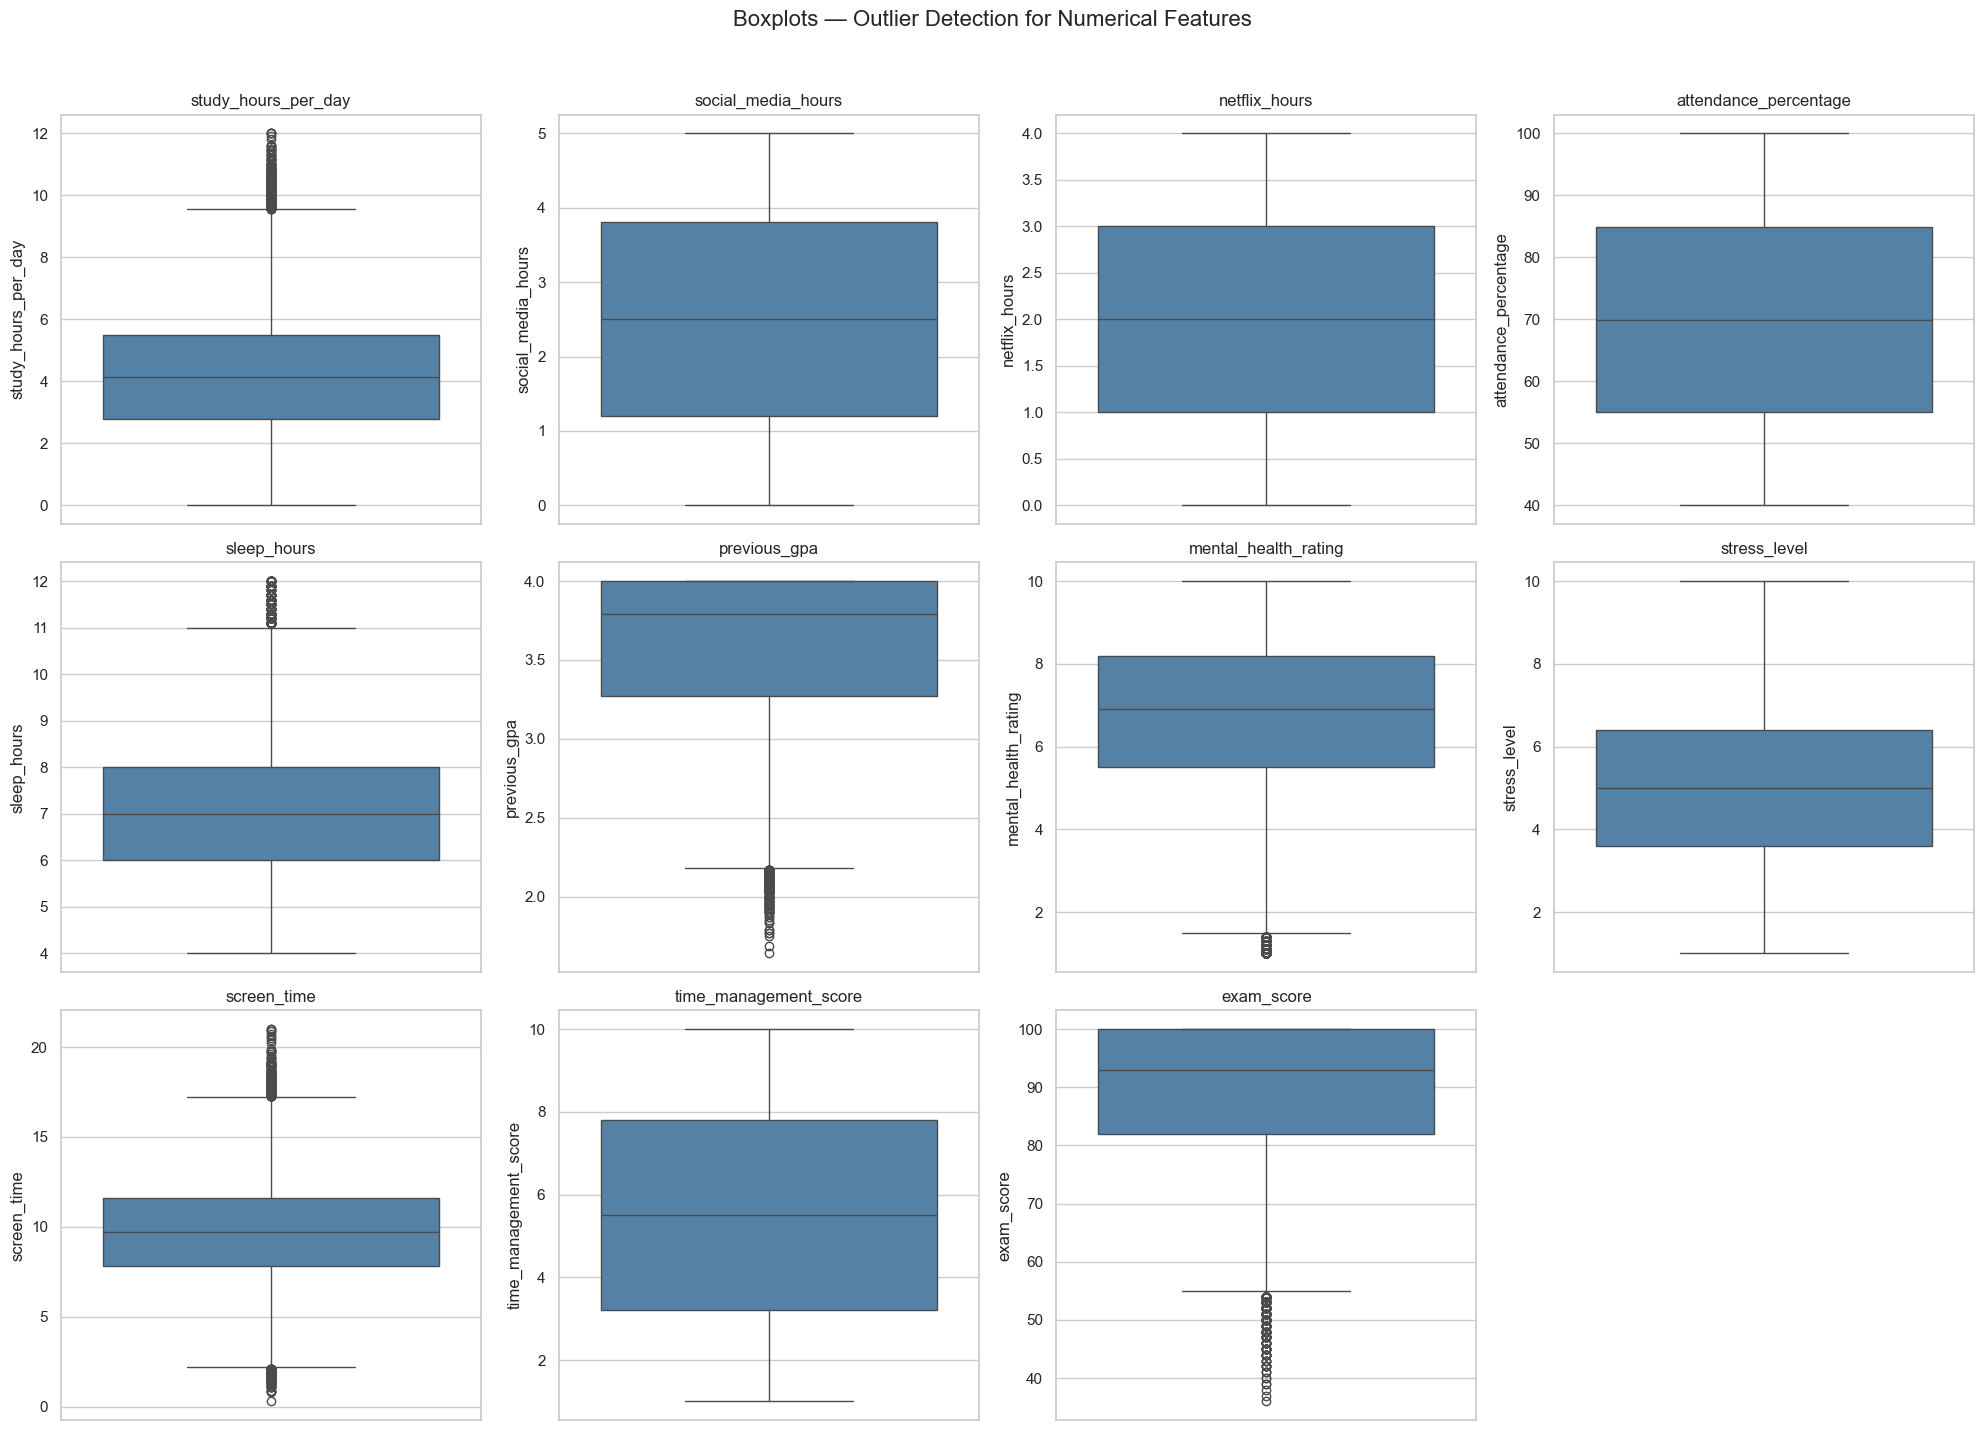

In [7]:
# Boxplots for numerical features
num_feats = ['study_hours_per_day', 'social_media_hours', 'netflix_hours',
             'attendance_percentage', 'sleep_hours', 'previous_gpa',
             'mental_health_rating', 'stress_level', 'screen_time',
             'time_management_score', 'exam_score']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(num_feats):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col)
for j in range(len(num_feats), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots — Outlier Detection for Numerical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


**📊 Chart Description:** Each boxplot displays the distribution of one numerical feature. The box represents the interquartile range (IQR: 25th–75th percentile), the horizontal line inside is the median, and points/whiskers extending beyond the box represent potential outliers. Observations to make: `study_hours_per_day` may show extreme values (>12h) that are unrealistic for daily study; `screen_time` may have high-end outliers suggesting data entry errors; `attendance_percentage` should remain within 0–100. These outliers could distort regression if left untreated.


In [8]:
# Winsorize / cap outliers at domain boundaries
bounds = {
    'study_hours_per_day': (0, 16),
    'sleep_hours': (2, 14),
    'attendance_percentage': (0, 100),
    'mental_health_rating': (1, 10),
    'stress_level': (1, 10),
    'motivation_level': (1, 10),
    'exam_anxiety_score': (1, 10),
    'time_management_score': (1, 10),
    'screen_time': (0, 24),
    'previous_gpa': (0.0, 4.0),
    'exercise_frequency': (0, 7),
    'social_media_hours': (0, 12),
    'netflix_hours': (0, 12),
}

for col, (low, high) in bounds.items():
    if col in df.columns:
        before = df[col].clip(lower=low, upper=high)
        changed = (df[col] != before).sum()
        df[col] = before
        print(f"{col}: {changed} values clipped to [{low}, {high}]")


study_hours_per_day: 0 values clipped to [0, 16]
sleep_hours: 0 values clipped to [2, 14]
attendance_percentage: 0 values clipped to [0, 100]
mental_health_rating: 0 values clipped to [1, 10]
stress_level: 0 values clipped to [1, 10]
motivation_level: 0 values clipped to [1, 10]
exam_anxiety_score: 0 values clipped to [1, 10]
time_management_score: 0 values clipped to [1, 10]
screen_time: 0 values clipped to [0, 24]
previous_gpa: 0 values clipped to [0.0, 4.0]
exercise_frequency: 0 values clipped to [0, 7]
social_media_hours: 0 values clipped to [0, 12]
netflix_hours: 0 values clipped to [0, 12]


## 📈 Step 6: Exploratory Data Analysis
EDA is the cornerstone of understanding the data before modeling.
We analyze:
1. Target variable distribution (exam_score)
2. Distribution of all numerical features
3. Correlation heatmap
4. Categorical feature distributions and their relationship to exam_score
5. Key bivariate relationships using scatter plots and violin plots
6. Feature-target correlations ranked by strength

### 6.1 — Target Variable Distribution


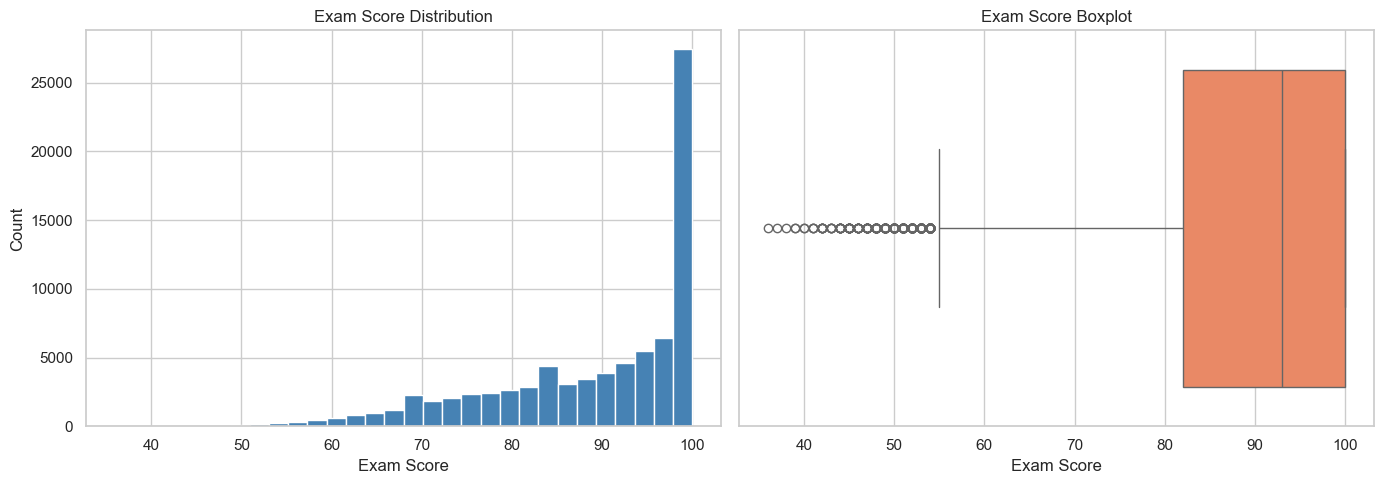

count    80000.000000
mean        89.141350
std         11.591497
min         36.000000
25%         82.000000
50%         93.000000
75%        100.000000
max        100.000000
Name: exam_score, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['exam_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Exam Score Distribution')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')

sns.boxplot(x=df['exam_score'], ax=axes[1], color='coral')
axes[1].set_title('Exam Score Boxplot')
axes[1].set_xlabel('Exam Score')

plt.tight_layout()
plt.show()

print(df['exam_score'].describe())


**📊 Chart Description:** The histogram reveals the shape of the exam score distribution — whether it is normally distributed, skewed, or bimodal. The boxplot confirms the median, spread, and any extreme outliers. If the distribution is left-skewed (piled at high scores), this suggests grade inflation or a generous exam. This informs whether log transformation of the target is needed before modeling.

### 6.2 — Numerical Features Distribution


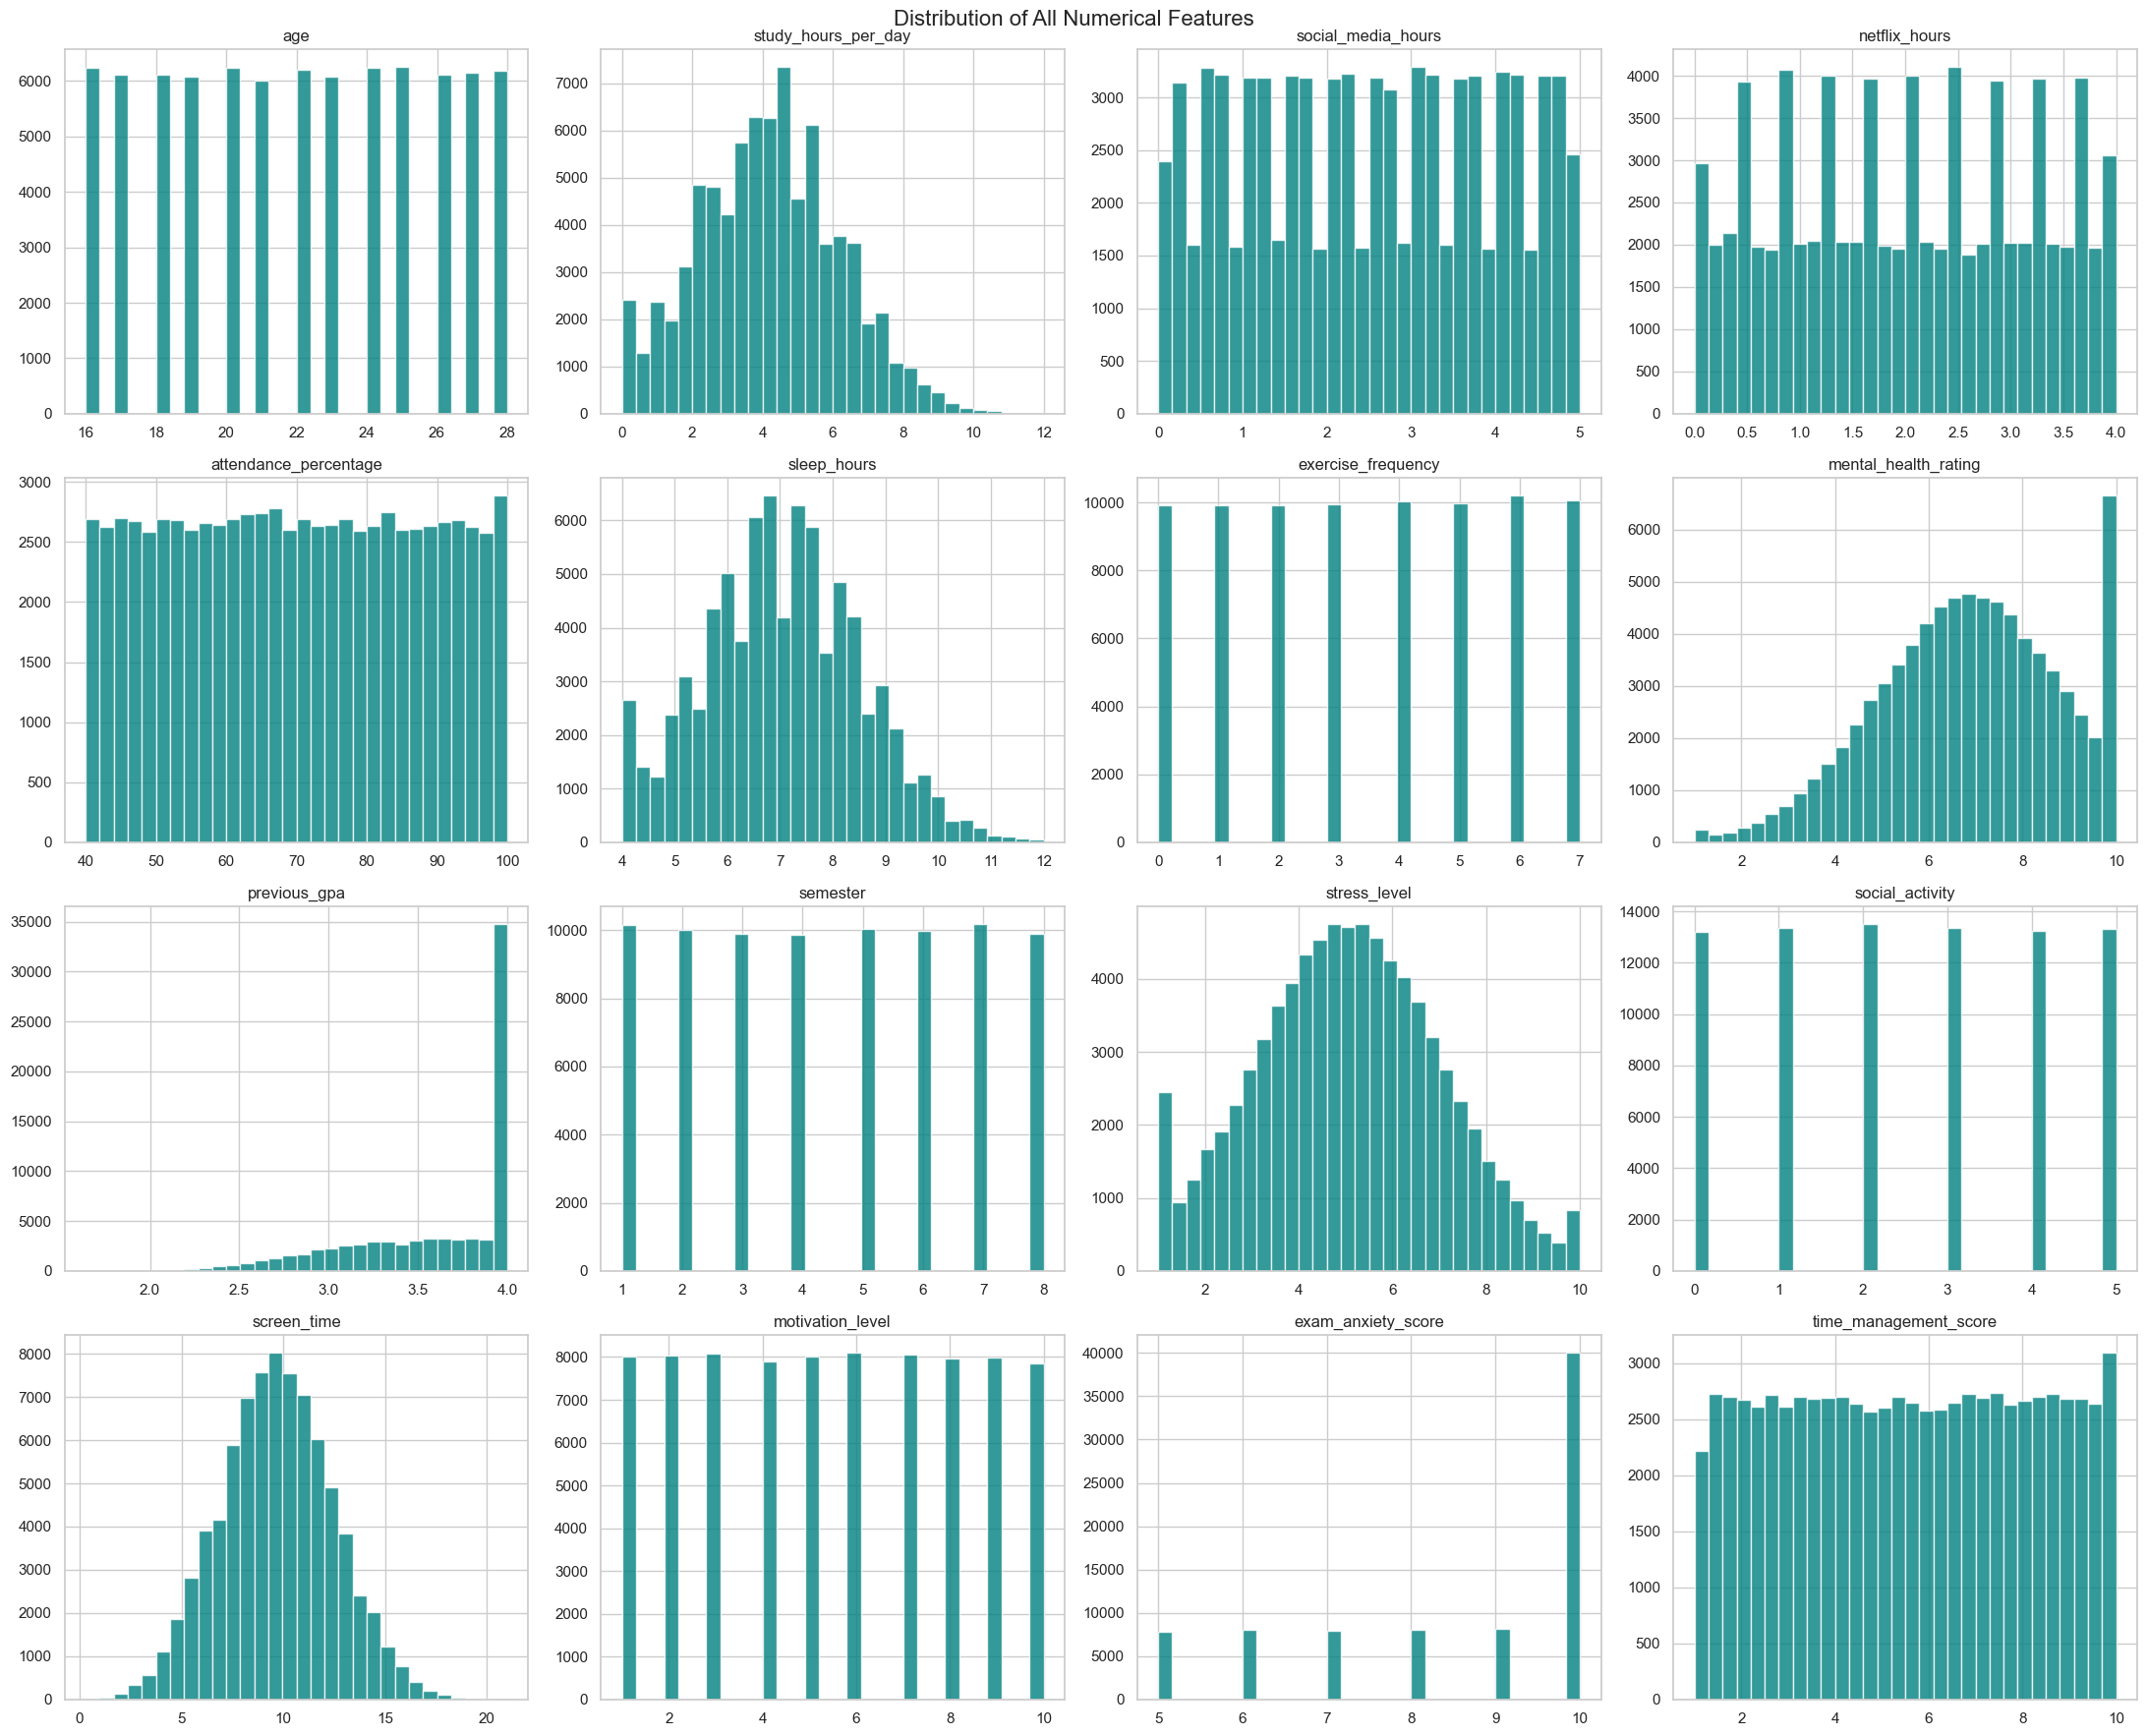

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('exam_score')

fig, axes = plt.subplots(4, 4, figsize=(22, 18))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribution of All Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


**📊 Chart Description:** Each mini-histogram shows the frequency distribution of one numerical feature. Look for: (a) skewness — `social_media_hours` and `netflix_hours` may be right-skewed since most students consume moderate amounts; (b) bimodality — `sleep_hours` may cluster around two distinct groups (night owls vs. normal sleepers); (c) uniform distributions — `exercise_frequency` may be fairly flat across 0–7 days. These distributions guide feature transformation decisions.

### 6.3 — Correlation Heatmap


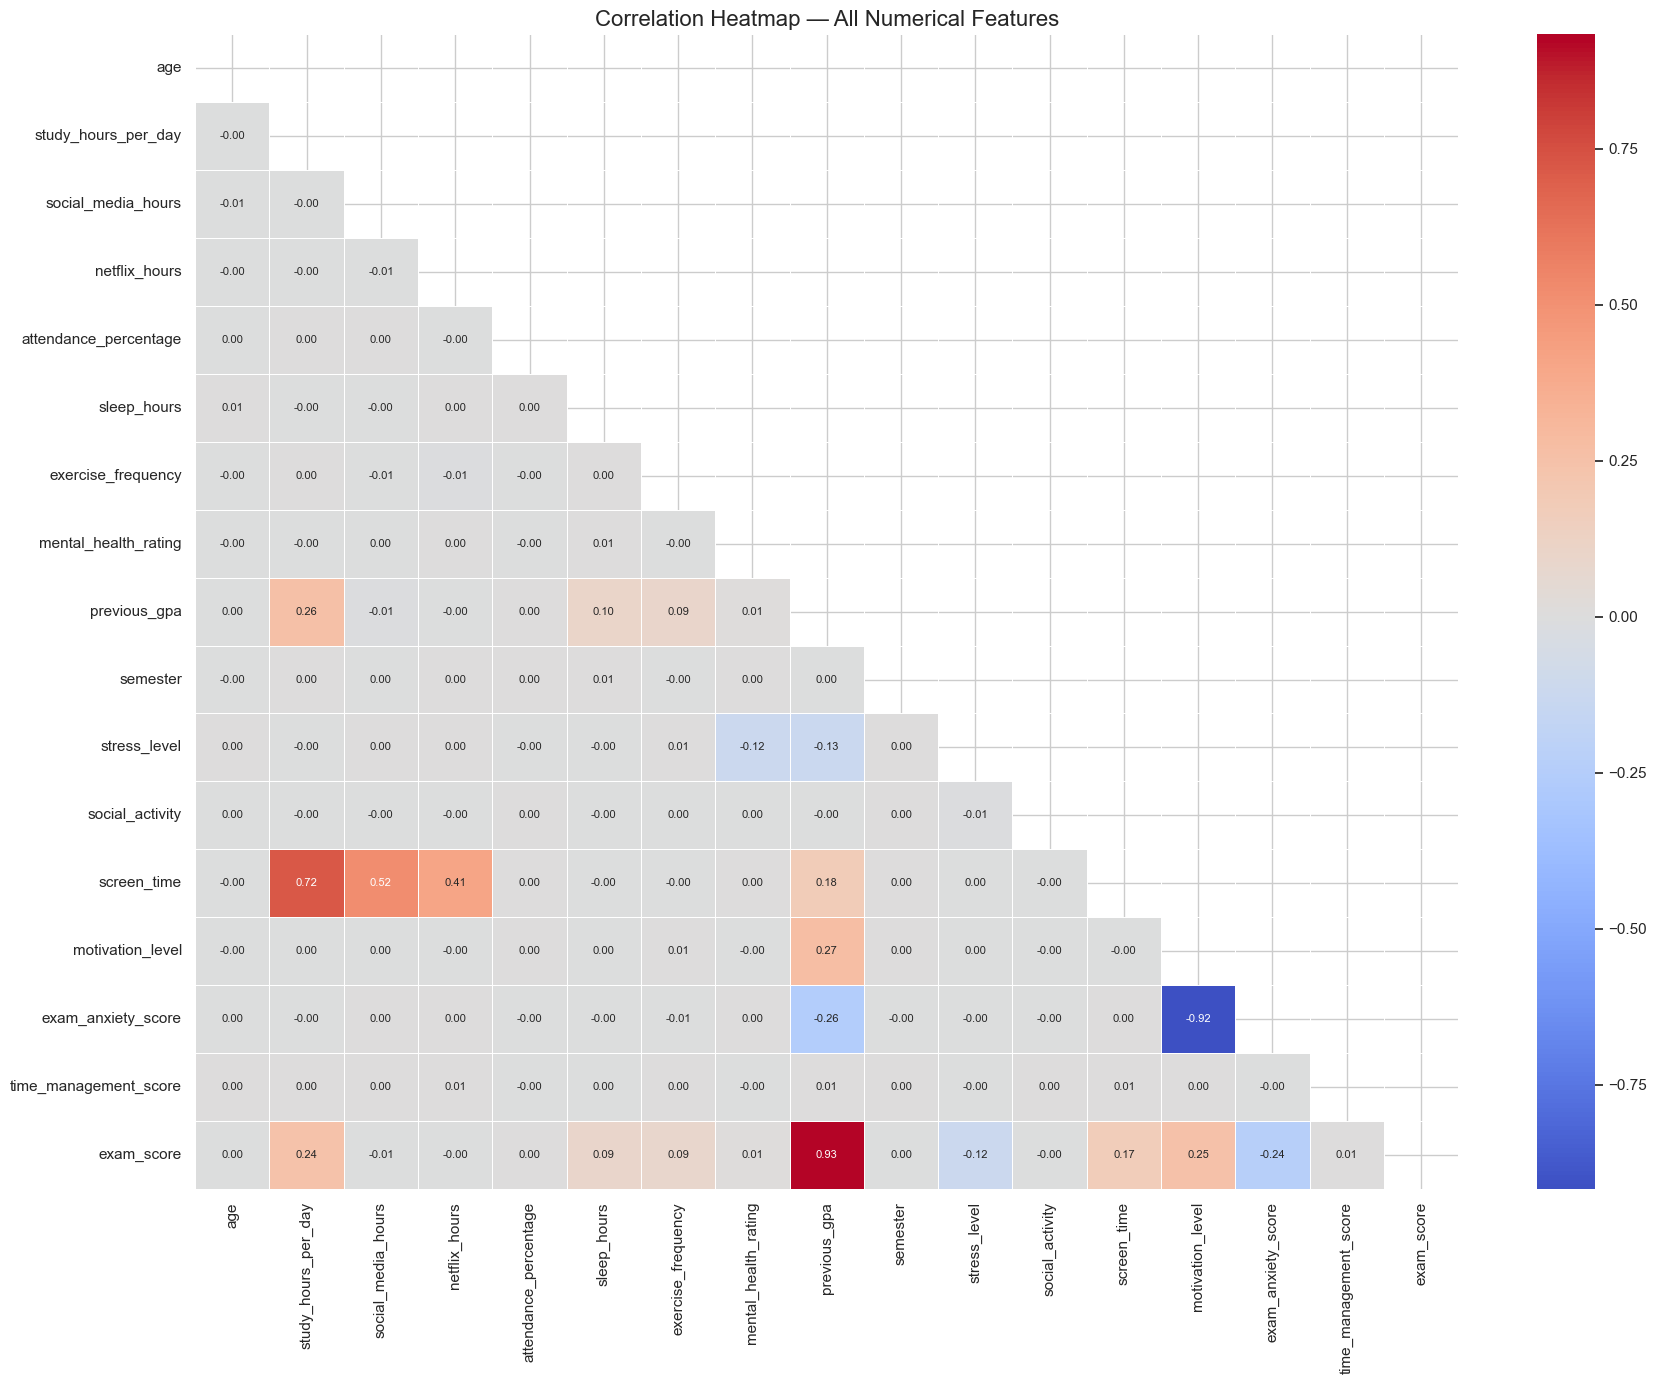

In [11]:
plt.figure(figsize=(18, 14))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap — All Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


**📊 Chart Description:** The correlation heatmap displays Pearson correlation coefficients between all pairs of numerical variables. Red = strong positive correlation, Blue = strong negative correlation, White ≈ no linear correlation. Key questions to answer from this chart: (1) Which features are most strongly correlated with `exam_score`? (2) Are there highly correlated pairs of features (multicollinearity) like `screen_time` vs. `social_media_hours`? (3) Does `study_hours_per_day` show the expected positive correlation with exam performance? Correlations above |0.7| between predictors indicate potential multicollinearity issues that may need addressing.

### 6.4 — Top Features Correlated with Exam Score


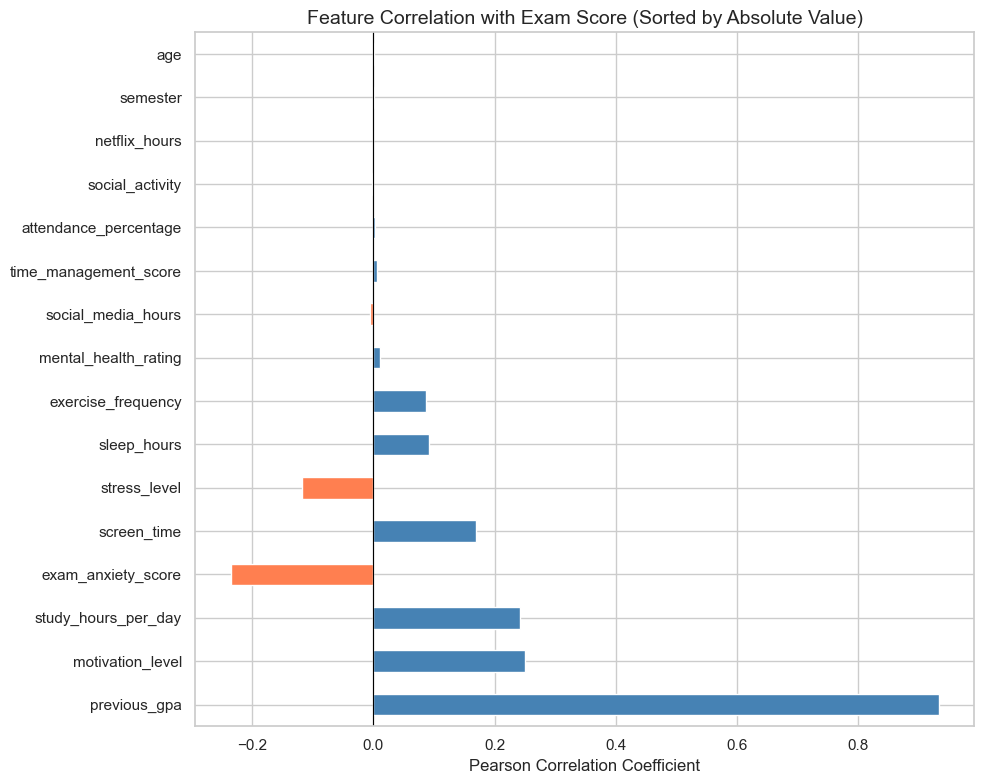

In [12]:
exam_corr = corr_matrix['exam_score'].drop('exam_score').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
colors = ['steelblue' if c > 0 else 'coral' for c in exam_corr]
exam_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Exam Score (Sorted by Absolute Value)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()


**📊 Chart Description:** This horizontal bar chart ranks all numerical features by their linear correlation strength with the target variable `exam_score`. Blue bars indicate positive relationships (feature increases → score increases), and coral/red bars indicate negative relationships. This is a quick first signal for which features are likely to be most informative for prediction. Note: correlation only captures linear relationships — non-linear importances will be revealed in the model-based feature importance steps.

### 6.5 — Categorical Feature Analysis


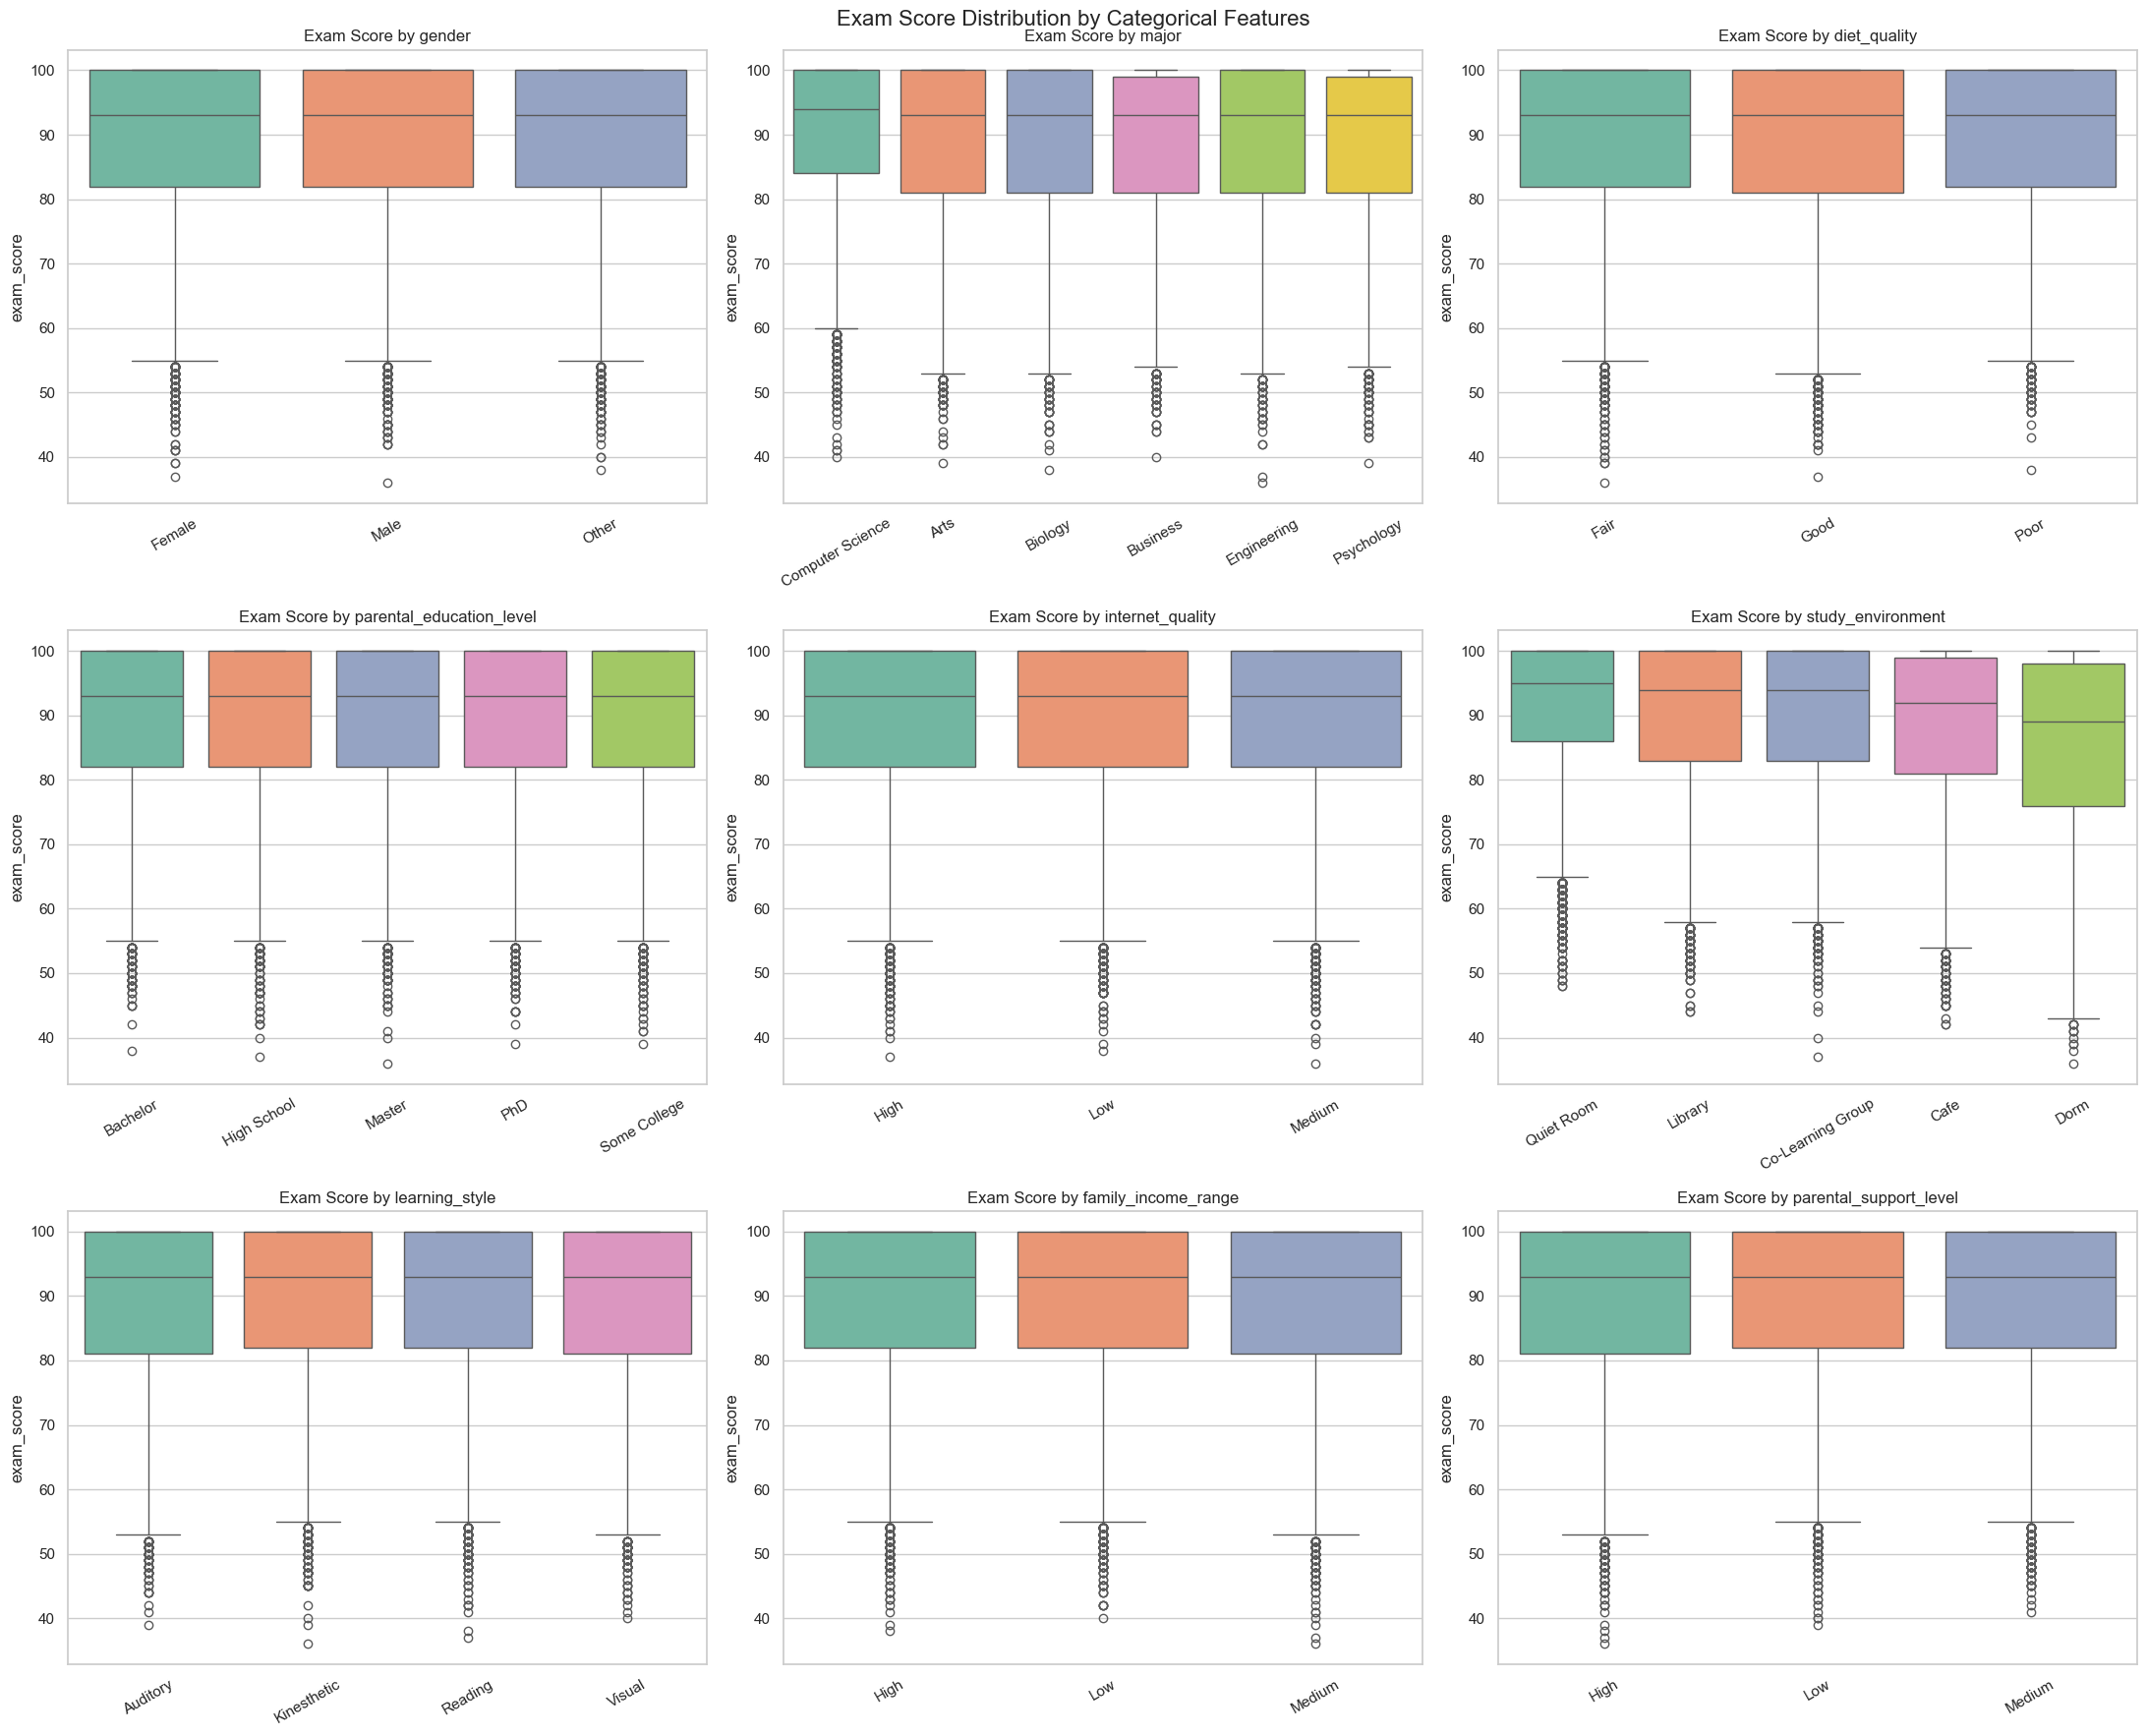

In [13]:
cat_cols = ['gender', 'major', 'diet_quality', 'parental_education_level',
            'internet_quality', 'study_environment', 'learning_style',
            'family_income_range', 'parental_support_level']

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df.groupby(col)['exam_score'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='exam_score', order=order, ax=axes[i],
                palette='Set2')
    axes[i].set_title(f'Exam Score by {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Exam Score Distribution by Categorical Features', fontsize=16)
plt.tight_layout()
plt.show()


**📊 Chart Description:** Each subplot shows a boxplot of exam scores segmented by one categorical variable. The median line inside each box enables direct comparison across categories. Insights to look for: (a) Does `parental_education_level` show a clear upward trend from High School → PhD? (b) Does `major` reveal significant score variation — do Engineering/CS students score higher? (c) Does `study_environment` show that Library or Quiet Room students outperform Dorm/Cafe students? These patterns will inform feature importance and potential interaction features.

### 6.6 — Key Scatter Plots (Continuous Features vs. Exam Score)


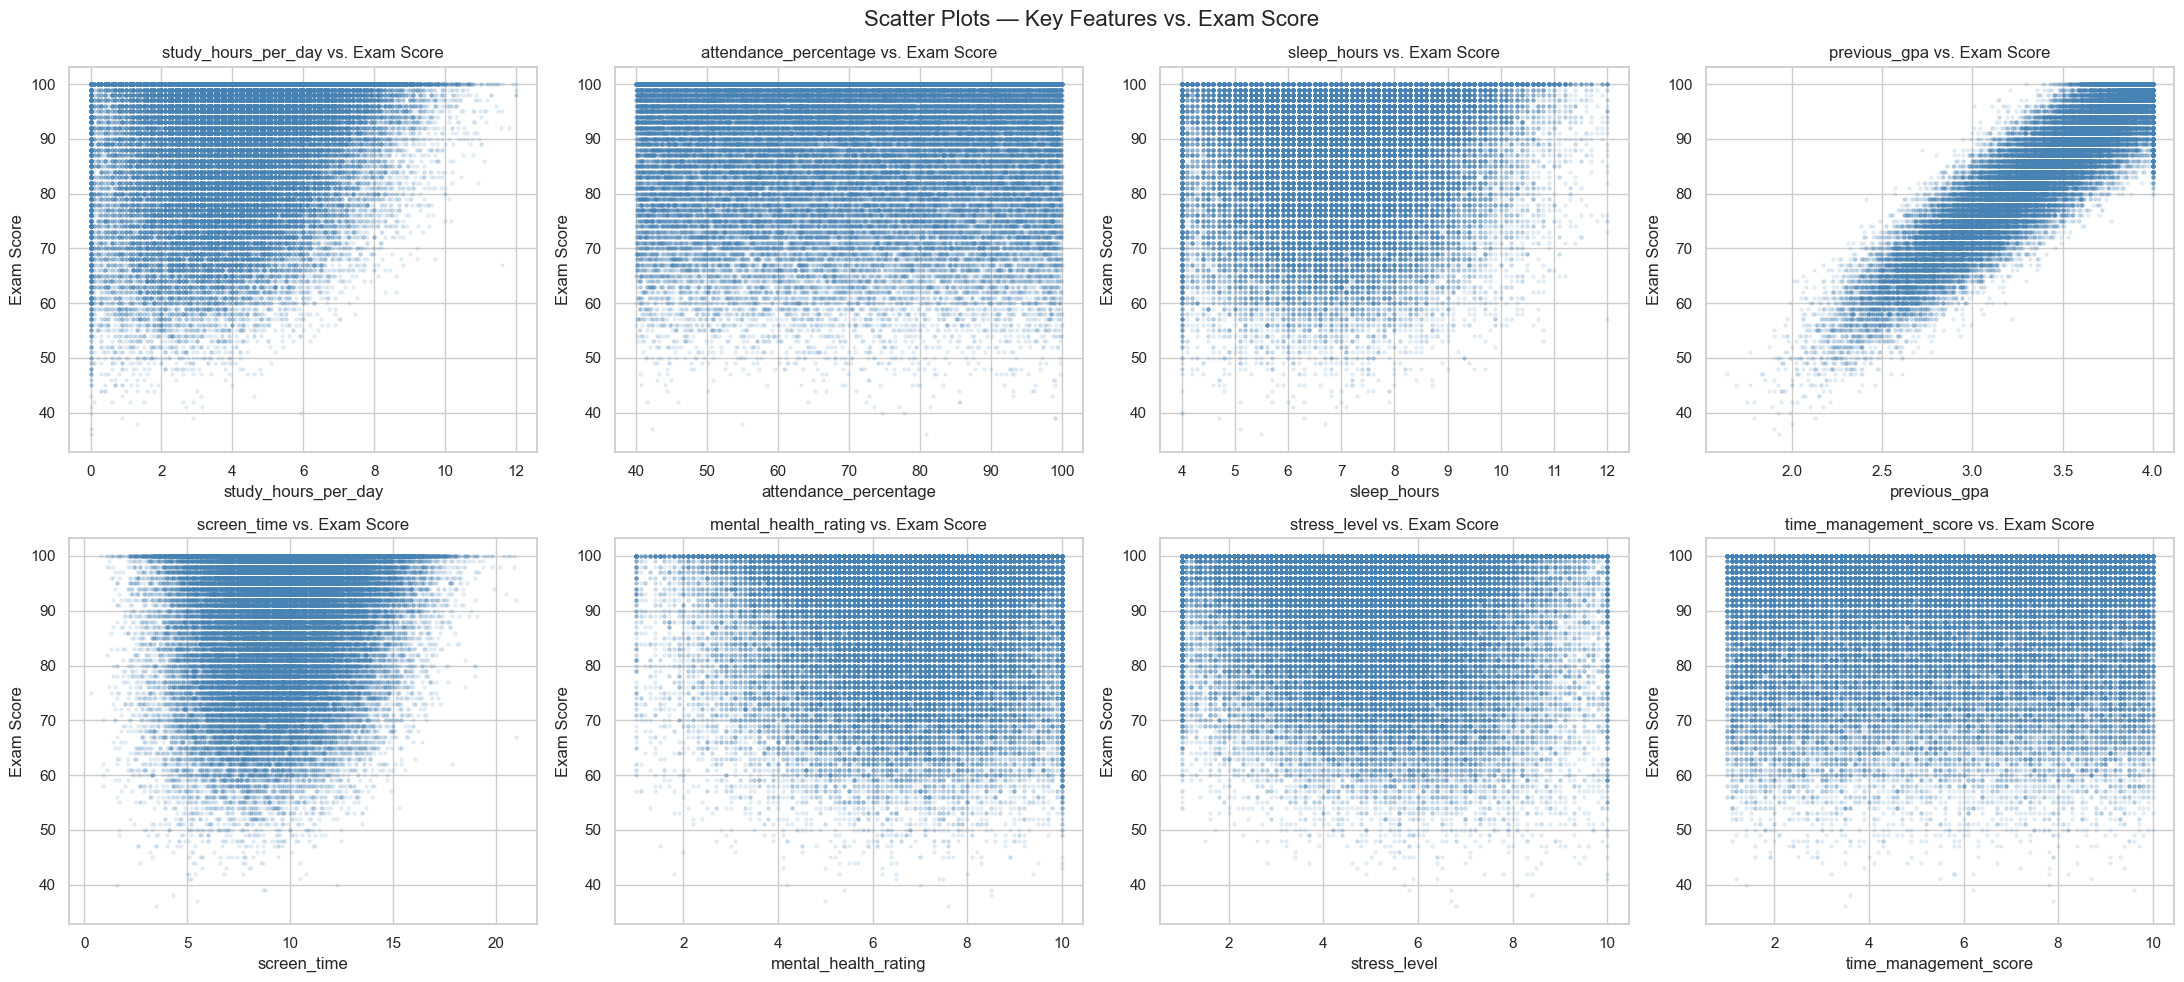

In [14]:
scatter_features = ['study_hours_per_day', 'attendance_percentage',
                    'sleep_hours', 'previous_gpa', 'screen_time', 
                    'mental_health_rating', 'stress_level', 'time_management_score']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for i, col in enumerate(scatter_features):
    axes[i].scatter(df[col], df['exam_score'], alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Exam Score')
    axes[i].set_title(f'{col} vs. Exam Score')
plt.suptitle('Scatter Plots — Key Features vs. Exam Score', fontsize=16)
plt.tight_layout()
plt.show()


**📊 Chart Description:** Each scatter plot reveals the raw relationship between a continuous feature and `exam_score`. A diagonal band of points indicates a linear relationship; a cloud with no pattern suggests low predictive value; a curved or fan-shaped pattern suggests non-linear behavior. Notable expectations: `study_hours_per_day` and `attendance_percentage` should show a positive relationship; `stress_level` and `screen_time` may show a negative relationship; `previous_gpa` is expected to be the strongest predictor. Observations about vertical banding indicate discrete data masquerading as continuous.

### 6.7 — Binary Features vs. Exam Score


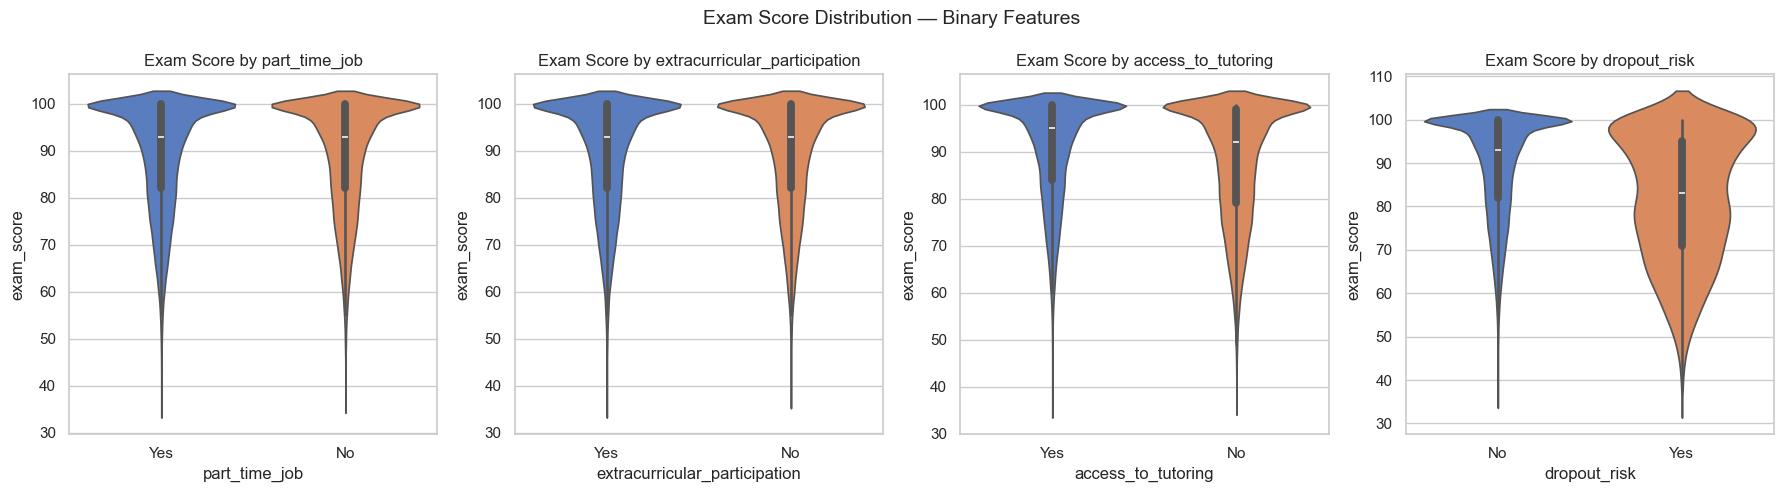

In [15]:
binary_cols = ['part_time_job', 'extracurricular_participation', 'access_to_tutoring', 'dropout_risk']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(binary_cols):
    sns.violinplot(data=df, x=col, y='exam_score', ax=axes[i], palette='muted')
    axes[i].set_title(f'Exam Score by {col}')
    axes[i].set_xlabel(col)
plt.suptitle('Exam Score Distribution — Binary Features', fontsize=14)
plt.tight_layout()
plt.show()


**📊 Chart Description:** Violin plots combine a boxplot and KDE (kernel density estimate) to show the full distribution shape for each category. For binary features (Yes/No), this tells us whether having a part-time job, extracurricular participation, or tutoring access significantly shifts the exam score distribution. Wide violin bodies indicate high score variability in that group; narrow bodies indicate concentrated scores. An interesting asymmetry (e.g., tutoring access showing a higher-median, tighter distribution) would support including these features as strong predictors.

## 🔤 Step 7: Encoding Categorical Variables & Feature Scaling
Machine learning models require all features to be numeric.
We apply:

**Ordinal Encoding** (preserving natural order):
- `diet_quality`: Poor < Fair < Good
- `parental_education_level`: High School < Some College < Bachelor < Master < PhD
- `internet_quality`: Low < Medium < High
- `family_income_range`: Low < Medium < High
- `parental_support_level`: Low < Medium < High

**Binary Encoding** (0/1):
- `part_time_job`, `extracurricular_participation`, `access_to_tutoring`, `dropout_risk`, `gender` (Male/Female/Other — use one-hot)

**One-Hot Encoding** (no ordinal relationship):
- `major`, `study_environment`, `learning_style`, `gender`

**Feature Scaling** (StandardScaler):
- Applied AFTER encoding, to numerical and ordinal features
- Required for SVR and Ridge/Lasso; tree models do not need it but we scale for consistency
- Scaling is fit ONLY on the training set and applied to test set (no leakage)


In [16]:
df_encoded = df.copy()

# 1. Ordinal Encoding
ordinal_mappings = {
    'diet_quality': ['Poor', 'Fair', 'Good'],
    'parental_education_level': ['High School', 'Some College', 'Bachelor', 'Master', 'PhD'],
    'internet_quality': ['Low', 'Medium', 'High'],
    'family_income_range': ['Low', 'Medium', 'High'],
    'parental_support_level': ['Low', 'Medium', 'High'],
}

for col, order in ordinal_mappings.items():
    enc = OrdinalEncoder(categories=[order])
    df_encoded[col] = enc.fit_transform(df_encoded[[col]])

# 2. Binary Encoding
binary_map = {'Yes': 1, 'No': 0}
for col in ['part_time_job', 'extracurricular_participation', 'access_to_tutoring', 'dropout_risk']:
    df_encoded[col] = df_encoded[col].map(binary_map)

# 3. One-Hot Encoding
ohe_cols = ['gender', 'major', 'study_environment', 'learning_style']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print("Columns:", df_encoded.columns.tolist())


Shape after encoding: (80000, 40)
Columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'previous_gpa', 'semester', 'stress_level', 'dropout_risk', 'social_activity', 'screen_time', 'access_to_tutoring', 'family_income_range', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'time_management_score', 'exam_score', 'gender_Male', 'gender_Other', 'major_Biology', 'major_Business', 'major_Computer Science', 'major_Engineering', 'major_Psychology', 'study_environment_Co-Learning Group', 'study_environment_Dorm', 'study_environment_Library', 'study_environment_Quiet Room', 'learning_style_Kinesthetic', 'learning_style_Reading', 'learning_style_Visual']


In [17]:
# Train/Test Split (80/20 stratified by exam_score bins)
X = df_encoded.drop(columns=['exam_score'])
y = df_encoded['exam_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# Feature Scaling (fit on train only)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("Scaling complete.")


Train size: (64000, 39), Test size: (16000, 39)
Scaling complete.


## 🔎 Step 8: Feature Selection — Filter, Wrapper & Embedded Methods
Feature selection reduces dimensionality, removes noise features, and can 
improve model generalization and interpretability. We apply three paradigms:

### Method 1 — Filter Methods (Statistical Tests)
Filter methods rank features independently of any model using statistical scores.
We use:
- **Pearson Correlation** with target (already explored in EDA)
- **Mutual Information Regression** (captures non-linear relationships)
- **F-regression** (ANOVA F-test for linear relationship significance)
We select the Top 15 features from each filter method.

### Method 2 — Wrapper Methods (Recursive Feature Elimination)
RFE iteratively removes the least important features using a base estimator,
evaluating subsets of features by model performance.
We use **RFE with RandomForestRegressor** as the estimator, selecting Top 15 features.
Note: computationally expensive — use a small n_estimators value.

### Method 3 — Embedded Methods (L1 Regularization + Tree Importance)
Embedded methods perform feature selection as part of model training:
- **Lasso Regression (L1)**: Shrinks less important feature coefficients to exactly 0
- **Random Forest Feature Importance**: Measures mean impurity decrease across trees
- **XGBoost Feature Importance**: Uses gain-based importance scores
We select features with non-zero Lasso coefficients and top-N tree-based importances.

#### Method 1: Filter — Mutual Information & F-Regression


Filter (F-test) selected: ['study_hours_per_day', 'sleep_hours', 'exercise_frequency', 'previous_gpa', 'stress_level', 'dropout_risk', 'screen_time', 'access_to_tutoring', 'motivation_level', 'exam_anxiety_score', 'major_Computer Science', 'study_environment_Co-Learning Group', 'study_environment_Dorm', 'study_environment_Library', 'study_environment_Quiet Room']

Filter (Mutual Info) selected: ['study_hours_per_day', 'sleep_hours', 'parental_education_level', 'previous_gpa', 'stress_level', 'dropout_risk', 'screen_time', 'access_to_tutoring', 'parental_support_level', 'motivation_level', 'exam_anxiety_score', 'major_Engineering', 'major_Psychology', 'study_environment_Dorm', 'study_environment_Quiet Room']


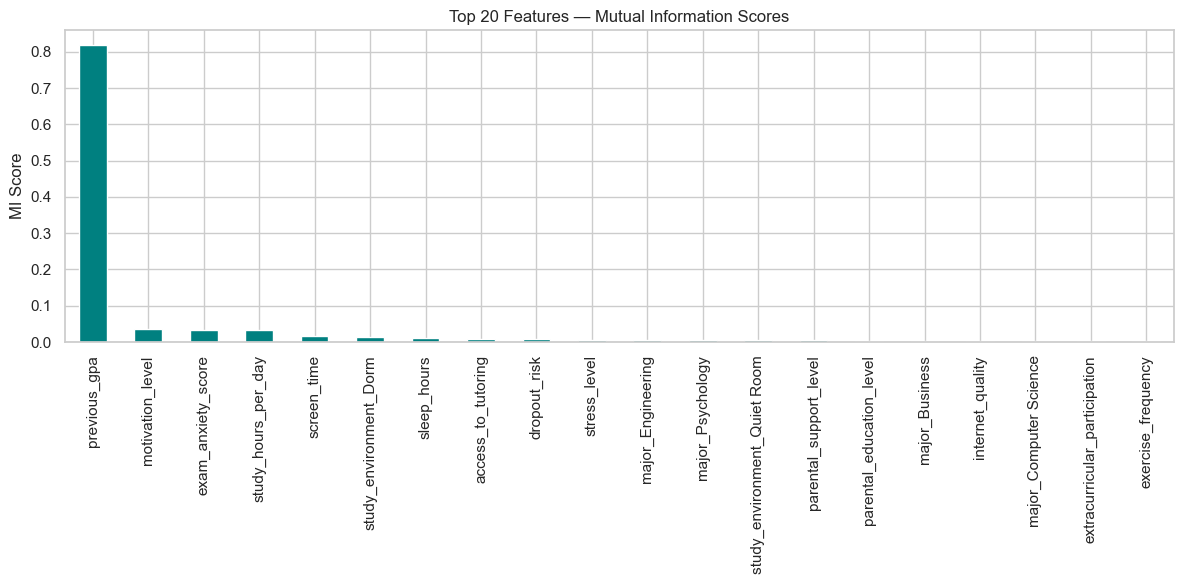

In [18]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

K = 15

# F-regression
selector_f = SelectKBest(score_func=f_regression, k=K)
selector_f.fit(X_train_scaled, y_train)
features_f = X_train_scaled.columns[selector_f.get_support()].tolist()

# Mutual Information
selector_mi = SelectKBest(score_func=mutual_info_regression, k=K)
selector_mi.fit(X_train_scaled, y_train)
features_mi = X_train_scaled.columns[selector_mi.get_support()].tolist()

print("Filter (F-test) selected:", features_f)
print("\nFilter (Mutual Info) selected:", features_mi)

# Visualization
fi_scores = pd.Series(selector_mi.scores_, index=X_train_scaled.columns).sort_values(ascending=False).head(20)
plt.figure(figsize=(12, 6))
fi_scores.plot(kind='bar', color='teal')
plt.title('Top 20 Features — Mutual Information Scores')
plt.ylabel('MI Score')
plt.tight_layout()
plt.show()


**📊 Chart Description:** The bar chart shows Mutual Information (MI) scores for the top 20 features relative to `exam_score`. MI measures how much knowing a feature reduces uncertainty about the target — unlike Pearson correlation, it captures non-linear relationships. Higher bars = more informative features. If `previous_gpa` and `study_hours_per_day` top the chart, it confirms our domain intuition. Surprising entries (e.g., `learning_style_Visual` ranking highly) would be worth investigating further.


In [19]:
# Prepare filtered datasets
X_train_filter = X_train_scaled[features_mi]
X_test_filter = X_test_scaled[features_mi]


#### Method 2: Wrapper — Recursive Feature Elimination (RFE)


In [20]:
from sklearn.feature_selection import RFE

rfe_estimator = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=15, step=5)
rfe.fit(X_train_scaled, y_train)

features_rfe = X_train_scaled.columns[rfe.support_].tolist()
print("Wrapper (RFE) selected:", features_rfe)

# Prepare RFE dataset
X_train_wrapper = X_train_scaled[features_rfe]
X_test_wrapper = X_test_scaled[features_rfe]


Wrapper (RFE) selected: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'previous_gpa', 'semester', 'stress_level', 'social_activity', 'screen_time', 'motivation_level', 'time_management_score']


#### Method 3: Embedded — Lasso & Random Forest Importance


Lasso selected 4 features


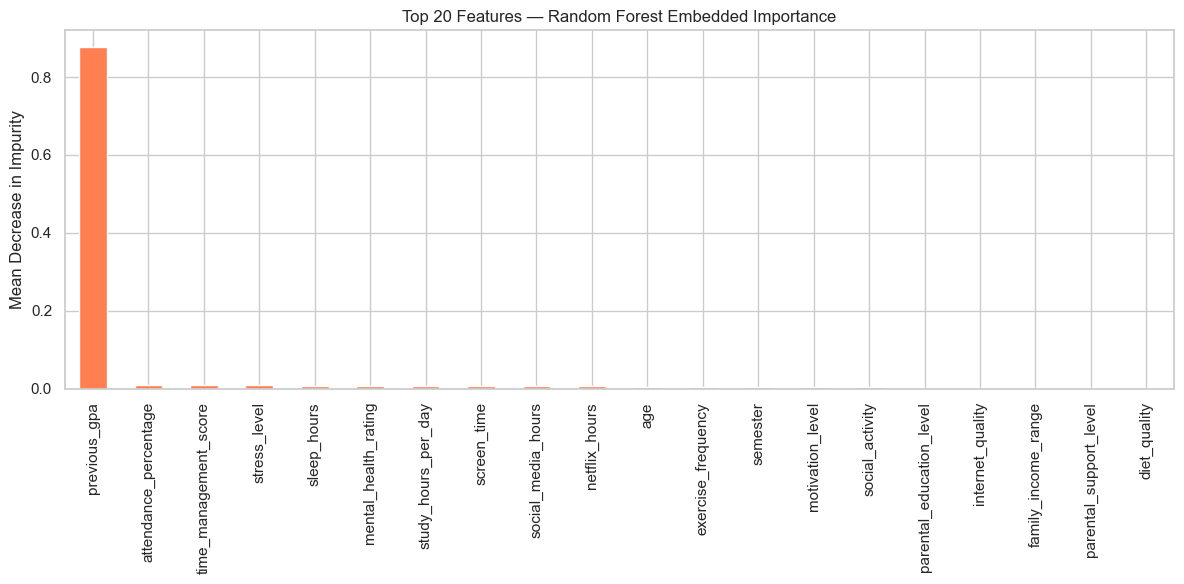

In [21]:
from sklearn.linear_model import LassoCV

# Lasso with Cross-Validated alpha
lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_train_scaled, y_train)

lasso_coefs = pd.Series(np.abs(lasso.coef_), index=X_train_scaled.columns)
features_lasso = lasso_coefs[lasso_coefs > 0].sort_values(ascending=False).index.tolist()
print(f"Lasso selected {len(features_lasso)} features")

# Random Forest Importance
rf_embed = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_embed.fit(X_train_scaled, y_train)
rf_importances = pd.Series(rf_embed.feature_importances_, index=X_train_scaled.columns)
features_rf_embed = rf_importances.sort_values(ascending=False).head(15).index.tolist()

# Use union of Lasso + RF top features (or intersection — choose based on dataset)
features_embedded = list(set(features_lasso[:15]).union(set(features_rf_embed)))

# Visualization: RF Importance
plt.figure(figsize=(12, 6))
rf_importances.sort_values(ascending=False).head(20).plot(kind='bar', color='coral')
plt.title('Top 20 Features — Random Forest Embedded Importance')
plt.ylabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()


**📊 Chart Description:** This bar chart shows Random Forest feature importances based on Mean Decrease in Impurity (MDI). Features with taller bars contribute more to reducing prediction error across all decision tree splits. This embedded method has the advantage of capturing complex non-linear and interaction effects that correlation-based methods miss. Compare these rankings with the Mutual Information scores — agreement between methods strengthens confidence that a feature is genuinely predictive.


In [22]:
X_train_embedded = X_train_scaled[features_embedded]
X_test_embedded = X_test_scaled[features_embedded]


## 🤖 Step 9: Model Training — 6 Powerful Regressors
We train and evaluate 6 models for each of the 3 feature selection sets (total: 18 experiments).
Models selected:
1. **Ridge Regression** — Linear baseline with L2 regularization
2. **Lasso Regression** — Linear model with built-in feature sparsity
3. **Random Forest Regressor** — Ensemble of decision trees, robust to noise
4. **Gradient Boosting Regressor** — Sequential boosting, handles non-linearities
5. **XGBoost Regressor** — Optimized gradient boosting, state-of-the-art performance
6. **LightGBM Regressor** — Highly efficient gradient boosting for large datasets

Evaluation Metrics:
- **RMSE** (Root Mean Squared Error) — penalizes large errors
- **MAE** (Mean Absolute Error) — average absolute prediction error
- **R² Score** (Coefficient of Determination) — proportion of variance explained
- **Cross-Validation R² (5-fold)** — model stability across data splits


In [23]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=5000),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
}

feature_sets = {
    'Filter (Mutual Info)': (X_train_filter, X_test_filter),
    'Wrapper (RFE)': (X_train_wrapper, X_test_wrapper),
    'Embedded (Lasso+RF)': (X_train_embedded, X_test_embedded),
}

results = []

for fs_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in models.items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        cv_r2 = cross_val_score(model, X_tr, y_train, cv=5, scoring='r2').mean()
        
        results.append({
            'Feature Selection': fs_name,
            'Model': model_name,
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4),
            'R²': round(r2, 4),
            'CV R²': round(cv_r2, 4),
        })
        print(f"[{fs_name}] {model_name} → RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))


[Filter (Mutual Info)] Ridge → RMSE: 4.1874 | MAE: 3.1956 | R²: 0.8705
[Filter (Mutual Info)] Lasso → RMSE: 4.1875 | MAE: 3.1967 | R²: 0.8705
[Filter (Mutual Info)] RandomForest → RMSE: 4.2548 | MAE: 3.3239 | R²: 0.8663
[Filter (Mutual Info)] GradientBoosting → RMSE: 4.1582 | MAE: 3.2199 | R²: 0.8723
[Filter (Mutual Info)] XGBoost → RMSE: 4.2162 | MAE: 3.2624 | R²: 0.8687
[Filter (Mutual Info)] LightGBM → RMSE: 4.1678 | MAE: 3.2271 | R²: 0.8717
[Wrapper (RFE)] Ridge → RMSE: 4.1881 | MAE: 3.1957 | R²: 0.8704
[Wrapper (RFE)] Lasso → RMSE: 4.1876 | MAE: 3.1967 | R²: 0.8705
[Wrapper (RFE)] RandomForest → RMSE: 4.2296 | MAE: 3.3081 | R²: 0.8679
[Wrapper (RFE)] GradientBoosting → RMSE: 4.1589 | MAE: 3.2216 | R²: 0.8722
[Wrapper (RFE)] XGBoost → RMSE: 4.2509 | MAE: 3.2841 | R²: 0.8665
[Wrapper (RFE)] LightGBM → RMSE: 4.1684 | MAE: 3.2280 | R²: 0.8717
[Embedded (Lasso+RF)] Ridge → RMSE: 4.1881 | MAE: 3.1959 | R²: 0.8704
[Embedded (Lasso+RF)] Lasso → RMSE: 4.1876 | MAE: 3.1969 | R²: 0.8705
[Emb

## 📊 Step 10: Results Visualization & Model Comparison
We now visualize and compare all 18 model-feature_selection combinations 
to identify the best pipeline configuration. 
Charts include: grouped bar charts by metric, heatmap of all results,
and the best model's prediction vs. actual plot.


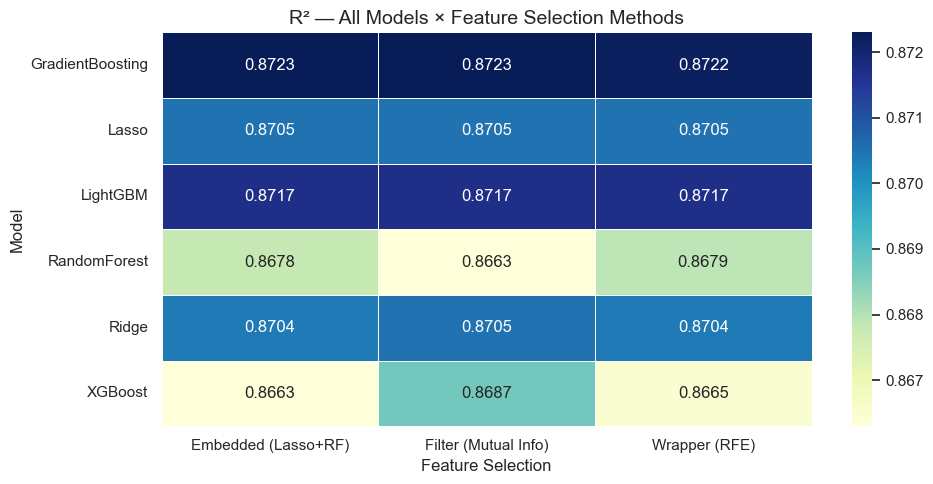

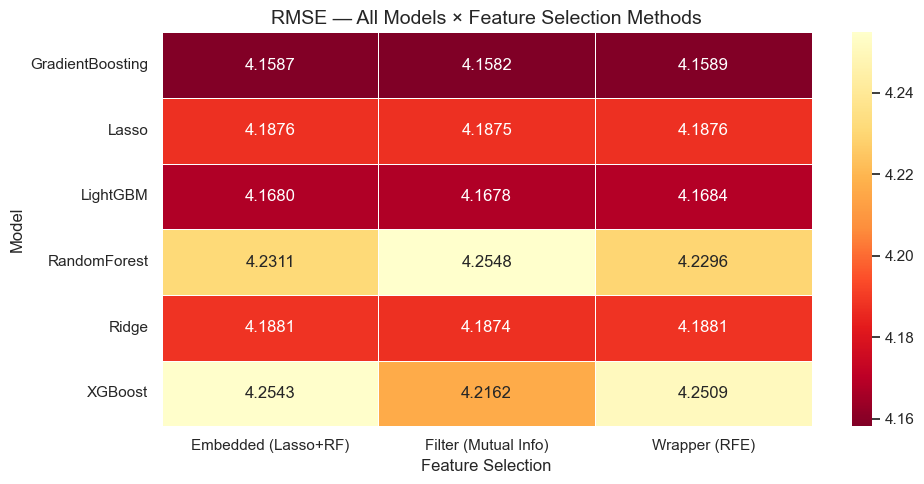

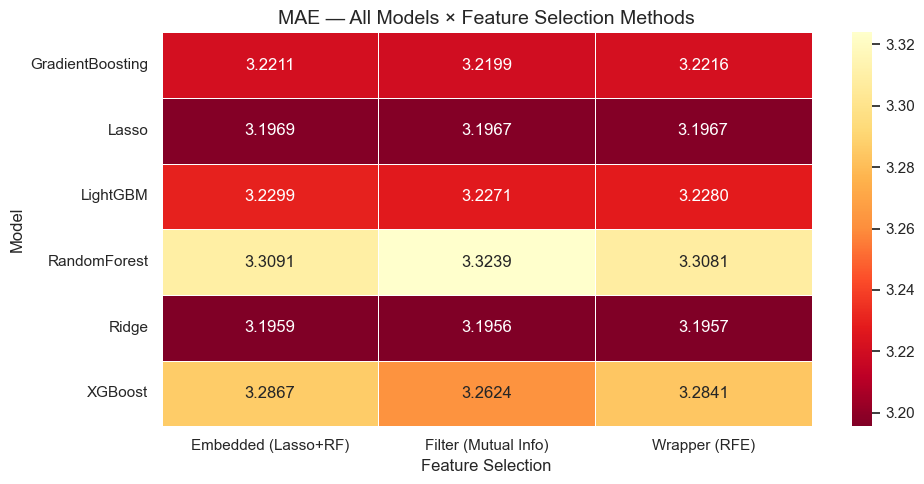

In [24]:
# Pivot for heatmap
for metric in ['R²', 'RMSE', 'MAE']:
    pivot = results_df.pivot(index='Model', columns='Feature Selection', values=metric)
    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu' if metric == 'R²' else 'YlOrRd_r',
                linewidths=0.5)
    plt.title(f'{metric} — All Models × Feature Selection Methods', fontsize=14)
    plt.tight_layout()
    plt.show()


**📊 Chart Description (R² Heatmap):** Each cell shows the R² score for a specific model (row) + feature selection method (column) combination. Darker cells indicate better performance (higher R²). This matrix answers: (1) Which model consistently performs best regardless of feature selection? (2) Does feature selection method significantly impact performance? (3) Are there synergistic combinations (e.g., XGBoost + Embedded outperforming XGBoost + Filter by a large margin)?


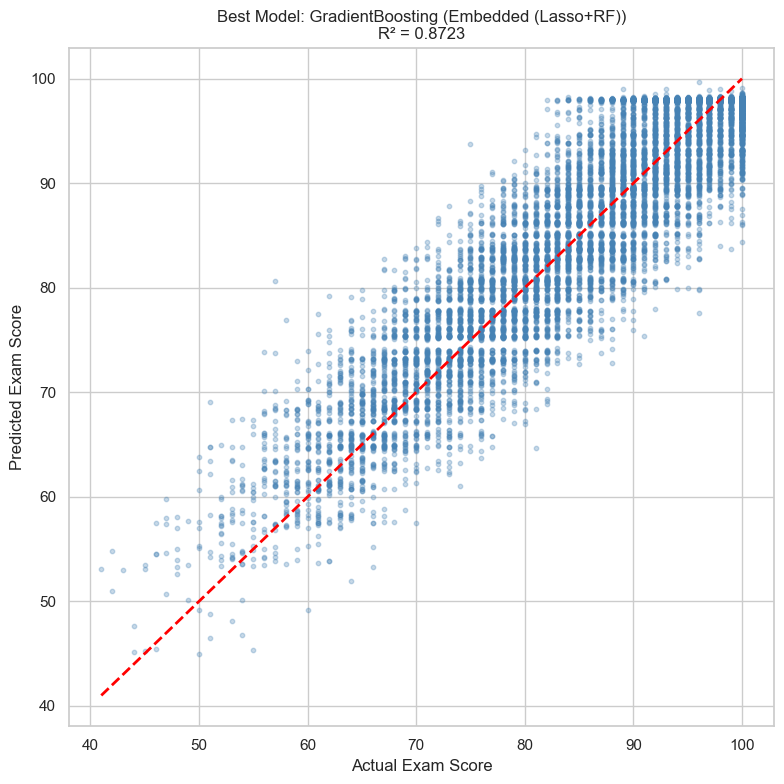

In [25]:
# Best model: Prediction vs. Actual
best_row = results_df.sort_values('R²', ascending=False).iloc[0]
best_model_name = best_row['Model']
best_fs_name = best_row['Feature Selection']
X_tr_best, X_te_best = feature_sets[best_fs_name]

best_model = models[best_model_name]
best_model.fit(X_tr_best, y_train)
y_pred_best = best_model.predict(X_te_best)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title(f'Best Model: {best_model_name} ({best_fs_name})\nR² = {best_row["R²"]}')
plt.tight_layout()
plt.show()


**📊 Chart Description:** This scatter plot compares actual exam scores (x-axis) against predicted scores (y-axis). The red dashed diagonal represents perfect prediction. Points close to the diagonal indicate accurate predictions. Systematic deviations — such as a fan shape (heteroscedasticity), curved patterns (missed non-linearity), or clusters of points far from the line — reveal weaknesses in the model. A tight cloud along the diagonal with high R² confirms strong predictive power.


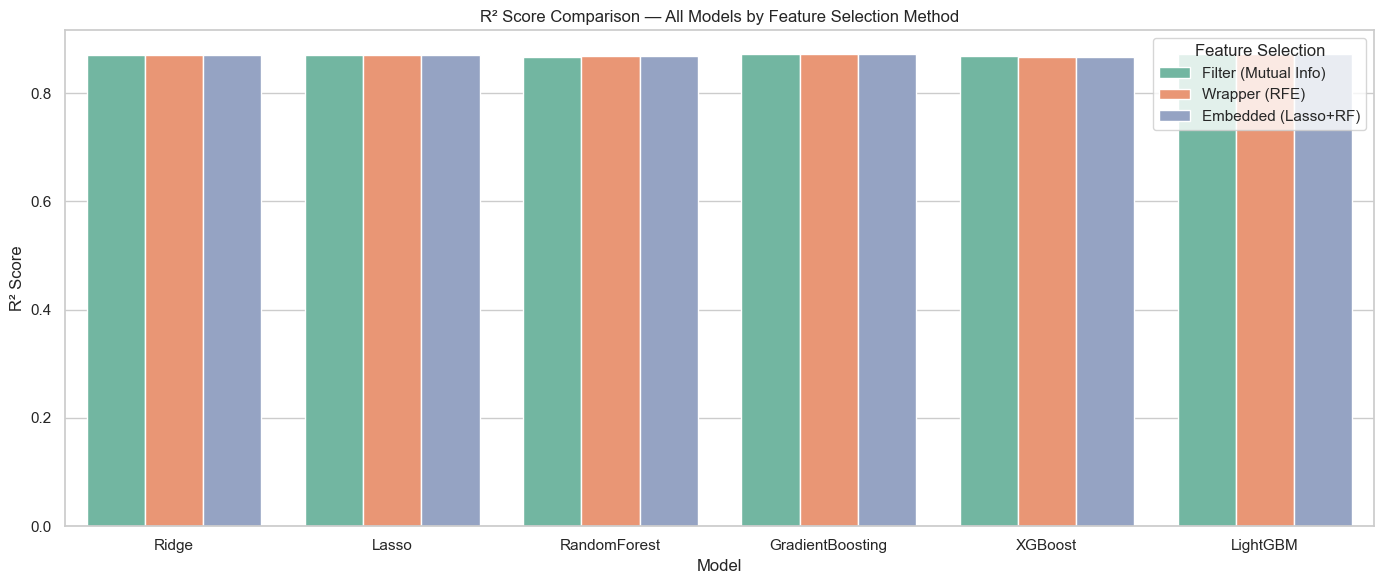

In [26]:
# Grouped bar chart: R² by model and feature selection
plt.figure(figsize=(14, 6))
sns.barplot(data=results_df, x='Model', y='R²', hue='Feature Selection', palette='Set2')
plt.title('R² Score Comparison — All Models by Feature Selection Method')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.legend(title='Feature Selection')
plt.tight_layout()
plt.show()


**📊 Chart Description:** This grouped bar chart allows side-by-side comparison of R² performance across all models (x-axis), with colors distinguishing the three feature selection methods. This directly answers: "Is it better to use Filter, Wrapper, or Embedded feature selection for this dataset?" If bars within the same model group are similar heights across feature selection methods, it suggests the model is robust to feature selection choice. If one color consistently produces taller bars, that feature selection strategy is most effective.


In [27]:
# Final summary table
print("\n🏆 FINAL MODEL PERFORMANCE SUMMARY (Sorted by R²)")
print(results_df.sort_values('R²', ascending=False).to_string(index=False))



🏆 FINAL MODEL PERFORMANCE SUMMARY (Sorted by R²)
   Feature Selection            Model   RMSE    MAE     R²  CV R²
 Embedded (Lasso+RF) GradientBoosting 4.1587 3.2211 0.8723 0.8722
Filter (Mutual Info) GradientBoosting 4.1582 3.2199 0.8723 0.8722
       Wrapper (RFE) GradientBoosting 4.1589 3.2216 0.8722 0.8721
 Embedded (Lasso+RF)         LightGBM 4.1680 3.2299 0.8717 0.8710
       Wrapper (RFE)         LightGBM 4.1684 3.2280 0.8717 0.8711
Filter (Mutual Info)         LightGBM 4.1678 3.2271 0.8717 0.8713
Filter (Mutual Info)            Lasso 4.1875 3.1967 0.8705 0.8703
Filter (Mutual Info)            Ridge 4.1874 3.1956 0.8705 0.8703
 Embedded (Lasso+RF)            Lasso 4.1876 3.1969 0.8705 0.8703
       Wrapper (RFE)            Lasso 4.1876 3.1967 0.8705 0.8703
 Embedded (Lasso+RF)            Ridge 4.1881 3.1959 0.8704 0.8703
       Wrapper (RFE)            Ridge 4.1881 3.1957 0.8704 0.8703
Filter (Mutual Info)          XGBoost 4.2162 3.2624 0.8687 0.8663
       Wrapper (RFE)     R

## ✅ Step 11: Conclusions & Key Insights

Summarize your findings:
1. **Best Overall Model**: Identify which model + feature selection combination achieved the highest R² and lowest RMSE.
2. **Most Predictive Features**: Across all three feature selection methods, which features consistently appeared in top selections? (e.g., `previous_gpa`, `study_hours_per_day`, `attendance_percentage`)
3. **Feature Selection Comparison**: Did Wrapper (RFE) outperform simpler Filter methods? Did Embedded methods (Lasso/RF) provide the best balance of performance and interpretability?
4. **Dataset Quality Issues**: Summarize what was fixed (float precision, encoding issues, outliers).
5. **Business/Educational Insights**: What behavioral or demographic factors most strongly predict exam success? Are there surprising findings (e.g., screen_time vs. sleep balance)?
6. **Future Work**: Suggest next steps — hyperparameter tuning (GridSearchCV/Optuna), deep learning models (TabNet, MLP), SHAP values for interpretability, or deployment via Flask/FastAPI.


In [28]:
print("Pipeline complete.")
print(f"\nBest model: {best_model_name}")
print(f"Best feature selection: {best_fs_name}")
print(f"Best R²: {best_row['R²']}")
print(f"Best RMSE: {best_row['RMSE']}")

import pickle
import joblib # standard for sklearn models

# Save the best model
model_filename = 'best_student_model.pkl'
joblib.dump(best_model, model_filename)

print(f"\n✅ Best model gracefully saved to: {model_filename}")


Pipeline complete.

Best model: GradientBoosting
Best feature selection: Embedded (Lasso+RF)
Best R²: 0.8723
Best RMSE: 4.1587


---

## 📌 IMPORTANT IMPLEMENTATION NOTES

1. **Run cells in order** — each step builds on the previous one; do not skip.
2. **Random seeds**: Use `random_state=42` throughout for reproducibility.
3. **No data leakage**: Scaler and encoders are **always** fitted on training data only, never on the full dataset or test set.
4. **The `screen_time` column** likely includes total screen time (social media + Netflix + study-related device use). Do not drop it without investigating its correlation with the other screen-related columns first.
5. **`dropout_risk`** is a binary column (Yes/No → 1/0 after encoding) and can be kept as a feature for predicting `exam_score` — students flagged as dropout risk may score differently.
6. **Computational note**: With ~80,000 rows, Gradient Boosting and RFE may take several minutes. Use `n_jobs=-1` wherever available to parallelize.
7. **If memory issues arise**: Use `df.sample(frac=0.3, random_state=42)` to work on 30% of the data for exploration, then switch to full data for final training.

---

*Prompt authored for the Student Habits & Performance ML Pipeline — Professional Notebook Edition*
*Dataset: enhanced_student_habits_performance_dataset.csv | ~80,000 records | Target: exam_score*


# Save the best Model

In [29]:
import pickle
import joblib # standard for sklearn models

# Save the best model
model_filename = 'best_student_model.pkl'
joblib.dump(best_model, model_filename)

print(f"\n✅ Best model gracefully saved to: {model_filename}")



✅ Best model gracefully saved to: best_student_model.pkl
